In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('dataset/review_shopee.csv')

df.head()

,content,score,label
0,Atakkarmita syahputra,1,negatif
1,untuk admin shopee saya mohon kebijaksanaanya ...,4,positif
2,cobak kalok pembohong jangan di masukan di sop...,1,negatif
3,iklan tai,1,negatif
4,2 kali beli barang lwat apps ini lebih dari 4 ...,1,negatif


In [6]:
df.isnull().sum()

content    0
score      0
label      0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
X = df['content']
y = df['label']

In [9]:
df = df[df['label'] != 'netral']

In [10]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [11]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(X).toarray()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779556100.962578   11426 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

W0000 00:00:1779556101.167895   11426 cpu_allocator_impl.cc:82] Allocation of 64000000 exceeds 10% of free system memory.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7316 - loss: 0.6908 - val_accuracy: 0.8125 - val_loss: 0.4767
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8869 - loss: 0.3407 - val_accuracy: 0.8562 - val_loss: 0.3995
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9247 - loss: 0.2302 - val_accuracy: 0.8625 - val_loss: 0.4049
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9413 - loss: 0.1640 - val_accuracy: 0.8612 - val_loss: 0.4338
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9712 - loss: 0.1143 - val_accuracy: 0.8637 - val_loss: 0.4667
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0803 - val_accuracy: 0.8525 - val_loss: 0.5162
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0583 - val_accuracy: 0.8512 - val_loss: 0.5468
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9897 - loss: 0.0494 - val_accuracy: 0.

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8440 - loss: 0.6694  
Loss : 0.6694328188896179
Accuracy : 0.843999981880188


In [17]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [18]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.70      0.71      0.70       233
           1       0.15      0.06      0.09        34
           2       0.90      0.92      0.91       733

    accuracy                           0.84      1000
   macro avg       0.58      0.56      0.57      1000
weighted avg       0.83      0.84      0.84      1000



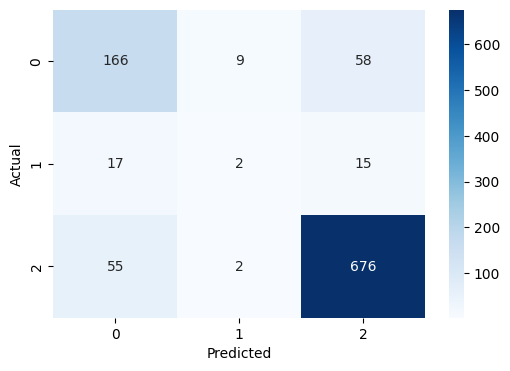

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
model.save('model/sentiment_model.h5')

In [21]:
import pickle

with open('model/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [22]:
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)